/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_13653/3103355922.py:99: RuntimeWarning: All-NaN slice encountered
  corrs = np.nanmedian(corrs, axis=0)
/opt/anaconda3/envs/np/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/opt/anaconda3/envs/np/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_13653/3103355922.py:99: RuntimeWarning: All-NaN slice encountered
  corrs = np.nanmedian(corrs, axis=0)
/opt/anaconda3/envs/np/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmed

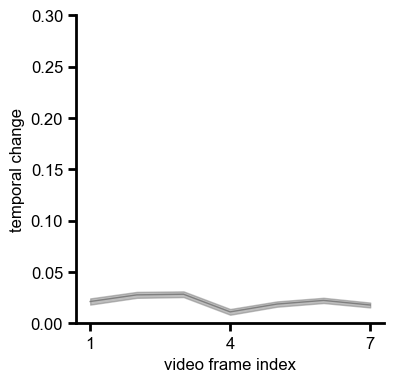

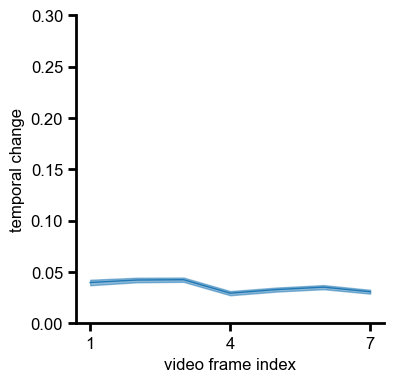

In [5]:
"""
Script: fig6_plot_temporal_change_ANN.py
This script analyzes and visualizes temporal changes in neural network activations
across different video understanding architectures. It compares static models
(using repeated frame features) with dynamic models (using temporal features)
by computing correlation decreases over time and comparing them to biological
neuron statistics.
Key functionalities:
- Loads temporal correlation data from HDF5 files for multiple neural network models
- Computes temporal changes in correlations (delta_corrs) across spatial and temporal dimensions
- Extracts early and late decline curve parameters for each model
- Generates temporal change plots for both static and dynamic model groups
- Creates comparative histograms showing model curve parameters vs. biological neuron statistics
- Overlays median values and biological neuron statistics (median absolute deviation) on visualizations
Output:
- Temporal change curves (PDF plots)
- Histogram comparisons of early and late decline parameters between models and biological neurons
"""

import sys
sys.path.append('../')

import h5py
import numpy as np
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
from utils.plot_utils import journal_figure_pdf, journal_figure
import scienceplots

plt.style.use(['nature'])

scores_path = '../../scores/figure7'

# Define static models (with repeated frame features)
static_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_repeated-frame_features_srp_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_repeated-frame_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'MatNet-FUS'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'TSDLv3-FUS'],
    "images_moving1_vjepa2-encoder.layer.16.mlp.fc2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2l'],
    "images_moving1_vjepa2g-encoder.layer.39.mlp.fc2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2g']
}

# Define dynamic models (with temporal features)
dynamic_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_features_srp_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'MatNet'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'FusionSeg'],
    "images_moving1_vjepa2-encoder.layer.16.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2l'],
    "images_moving1_vjepa2g-encoder.layer.39.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2g']
}

# Neural network neuron statistics (median and median absolute deviation)
neurons_params_median = [0.2703563510431904, 0.10990032606629607]
neurons_params_err = [0.006151076015271371, 0.006786410970159389]


# Initialize arrays to store results
repetitions = 10
curve_params_all = np.zeros((len(static_models) + len(dynamic_models), 1000, 2)) + np.nan
delta_corrs_all = np.zeros((len(static_models) + len(dynamic_models), 7, 1000)) + np.nan

# Process both static and dynamic models
for j, model_group in enumerate(['static_models', 'dynamic_models']):
    if model_group == 'static_models':
        model_color = 'tab:gray'
        models = static_models
    else:
        model_color = 'tab:blue'
        models = dynamic_models

    # Load and process each model
    for m, model in enumerate(models.keys()):
        neurons_file_path = f'{scores_path}/{model}/temporal_change_pearson.h5'
        neurons_h5_file = h5py.File(neurons_file_path, 'r')
        
        # Load correlations and compute median across repetitions
        corrs = np.array(neurons_h5_file['raw_correlations'])
        corrs = np.nanmedian(corrs, axis=0)

        # Downsample spatial dimensions by factor of 2
        corrs = corrs[0:corrs.shape[0]:2, 0:corrs.shape[1]:2, :]

        # Extract dimensions
        t_idxs = list(range(0, corrs.shape[1]-2))
        n_time_bins = corrs.shape[1]
        n_neurons = corrs.shape[-1]

        # Compute correlation statistics across neurons
        corrs_mean = np.nanmedian(corrs, axis=2)
        corrs_std = np.nanstd(corrs, axis=2)

        # Calculate temporal change in correlations (delta_corrs)
        delta_corrs = np.zeros((n_time_bins, n_neurons)) + np.nan

        t_start = t_idxs[0]
        end_time_bin_idx = t_idxs[-1]
        
        for n in range(n_neurons):
            for t in range(t_start, end_time_bin_idx+1):
                if t+2 < corrs.shape[0]:
                    delta_corrs[t, n] = corrs[t, t+1, n] - corrs[t, t+2, n]

        # Extract curve parameters (early and late decline)
        curve_params = np.zeros((repetitions, n_neurons, 2)) + np.nan

        for r in range(repetitions):
            for n in range(n_neurons):
                if np.isnan(delta_corrs[t_start:end_time_bin_idx+1, n]).any():
                    continue
                if np.isinf(delta_corrs[t_start:end_time_bin_idx+1, n]).any():
                    continue
                
                y = delta_corrs[t_start:end_time_bin_idx+1, n]
                curve_params[r, n, 0] = y[0]
                curve_params[r, n, 1] = y[-1]

        # Store aggregated results
        curve_params = np.nanmedian(curve_params, axis=0)
        delta_corrs_all[len(static_models) * j + m] = delta_corrs[t_start:end_time_bin_idx+1]
        curve_params_all[len(static_models) * j + m] = curve_params

    # Plot temporal change for current model group
    delta_corrs_all_ = np.nanmean(delta_corrs_all, axis=0)
    plt.figure(figsize=(5, 4))

    plt.errorbar(np.arange(delta_corrs_all_[t_start:end_time_bin_idx+1].shape[0]), 
                 np.nanmedian(delta_corrs_all_[t_start:end_time_bin_idx+1], -1), 
                 c=model_color, capsize=0, linestyle='-')
    
    plt.fill_between(np.arange(delta_corrs_all_[t_start:end_time_bin_idx+1].shape[0]), 
                     np.nanmedian(delta_corrs_all_[t_start:end_time_bin_idx+1], -1) - np.nanstd(delta_corrs_all_[t_start:end_time_bin_idx+1], -1),
                     np.nanmedian(delta_corrs_all_[t_start:end_time_bin_idx+1], -1) + np.nanstd(delta_corrs_all_[t_start:end_time_bin_idx+1], -1),
                     color=model_color, alpha=0.5)

    # Format x-axis labels
    labels = [i+1 for i in range(end_time_bin_idx+1 - t_start)]
    range_ = list(range(len(labels)))
    labels = labels[::3]
    range_ = range_[::3]

    plt.xticks(range_, labels, fontsize=6)
    plt.ylim([0., 0.3])
    plt.xlabel("video frame index", fontsize=12)
    plt.ylabel("temporal change", fontsize=12)

    journal_figure(do_save=True, filename=f'../../plots/figure7_temporal_change_ANN-{model_group}.eps')
    journal_figure_pdf(do_save=True, filename=f'../../plots/figure7_temporal_change_ANN-{model_group}.pdf')



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


spatiotemporal mean: 0.06 0.01
spatial mean: 0.02 0.0
Wilcoxon dynamic t-test: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(6.103515625e-05))
t-test dynamic vs. static: TtestResult(statistic=np.float64(4.625366358124501), pvalue=np.float64(0.00039304229396755605), df=np.int64(14))


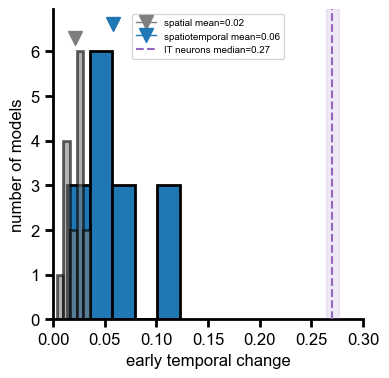

spatiotemporal mean: 0.04 0.01
spatial mean: 0.02 0.0
Wilcoxon dynamic t-test: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(6.103515625e-05))
t-test dynamic vs. static: TtestResult(statistic=np.float64(5.554667701177993), pvalue=np.float64(7.095861285135874e-05), df=np.int64(14))


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


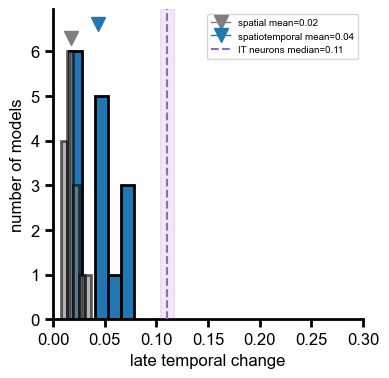

In [ ]:
import scipy

# Compare model curve parameters with biological neurons
for i, phase in enumerate(['early', 'late']):
    # Extract curve parameters for each model type
    static = np.nanmedian(curve_params_all[:len(static_models), :, i], 1)
    dynamic = np.nanmedian(curve_params_all[len(static_models):, :, i], 1)

    plt.figure(figsize=(4, 5))

    # Plot histograms 
    plt.hist(static, bins=5, color='tab:gray', edgecolor='black', density=False, linewidth=2, alpha=0.6, zorder=2)
    plt.hist(dynamic, bins=5, color='tab:blue', edgecolor='black', density=False, linewidth=2, zorder=1)
    plt.xlim([0.0, 0.3])

    # Overlay medians and biological neuron statistics
    plt.plot(np.nanmean(static), plt.ylim()[1] * 1.0, marker='v', color='tab:gray', markersize=10, zorder=2, label=f'spatial mean={np.round(np.nanmean(static), 2)}')
    plt.plot(np.nanmean(dynamic), plt.ylim()[1] * 1.0, marker='v', color='tab:blue', markersize=10, zorder=1, label=f'spatiotemporal mean={np.round(np.nanmean(dynamic), 2)}')

    print('spatiotemporal mean:', np.round(np.nanmean(dynamic), 2), np.round(np.nanstd(dynamic) / np.sqrt(len(dynamic)), 2))
    print('spatial mean:', np.round(np.nanmean(static), 2), np.round(np.nanstd(static) / np.sqrt(len(static)), 2))
    #print('Wilcoxon dynamic t-test:', stats.ranksums(dynamic, neurons_params_median[i]))
    print('Wilcoxon dynamic t-test:', scipy.stats.wilcoxon(dynamic - neurons_params_median[i], alternative="two-sided"))
    print('t-test dynamic vs. static:', stats.ttest_rel(dynamic, static, nan_policy='omit'))

    plt.axvline(neurons_params_median[i], color='tab:purple', linestyle='--', linewidth=1.5, label=f'IT neurons median={np.round(neurons_params_median[i], 3)}', zorder=3)
    plt.axvspan(neurons_params_median[i] - neurons_params_err[i], neurons_params_median[i] + neurons_params_err[i], color='tab:purple', alpha=0.15, zorder=3)
    

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel(f"{phase} temporal change", fontsize=12) 
    plt.ylabel("number of models", fontsize=12)

    # Save figure
    journal_figure(do_save=True, filename=f'../../plots/figure7_temporal_change_ANN_{phase}_model_hist.eps')
    journal_figure_pdf(do_save=True, filename=f'../../plots/figure7_temporal_change_ANN_{phase}_model_hist.pdf')
    plt.show()
